# Rolling Sharpe Portfolio Backtest

This notebook backtests three portfolio variants across the 30 representative GLBX continuous futures contracts. The variants use close-to-close daily returns derived from the Databento `ohlcv-1m` daily close cache.

Backtested variants:

1. `risk_parity_baseline`: long-only inverse-volatility risk allocation.
2. `sharpe_tilt_long_short`: long positive rolling-Sharpe assets and short negative rolling-Sharpe assets, scaled by inverse volatility.
3. `sharpe_tilt_sector_balanced`: same rolling-Sharpe tilt, but each sector receives equal gross risk budget before portfolio volatility targeting.

Signals are computed using information available at the close, rebalanced weekly, and shifted by one observation before portfolio returns are calculated.

In [1]:
from __future__ import annotations

from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

plt.style.use("seaborn-v0_8-whitegrid")
pd.set_option("display.max_columns", 100)
pd.set_option("display.max_rows", 200)

## Parameters

The cost assumption is deliberately simple: one-way basis points on notional turnover. This lets us compare variants consistently, but it is not a final execution model.

In [2]:
DATA_PATH = (
    Path("../..")
    / "data"
    / "features"
    / "databento_glbx_representative"
    / "daily_close_to_close.parquet"
)

TRADING_DAYS_PER_YEAR = 252
SHARPE_WINDOW = 30
ASSET_VOL_WINDOW = 30
PORTFOLIO_VOL_WINDOW = 60
REBALANCE_FREQUENCY = "W-FRI"
TARGET_VOL = 0.10
MAX_LEVERAGE = 3.0
COST_BPS = 1.0

DATA_PATH.resolve()

PosixPath('/home/famadeo/quant-lab/data/features/databento_glbx_representative/daily_close_to_close.parquet')

## Load Close-To-Close Returns

In [3]:
daily = pd.read_parquet(DATA_PATH)
daily["date"] = pd.to_datetime(daily["date"])

meta = (
    daily[["category", "symbol", "root", "description"]]
    .drop_duplicates()
    .sort_values(["category", "symbol"])
    .reset_index(drop=True)
)

prices_raw = daily.pivot(index="date", columns="symbol", values="close").sort_index()
prices = prices_raw.ffill()
live = prices.notna()
returns = prices.pct_change().where(live).fillna(0.0)

print(f"Date range: {returns.index.min().date()} to {returns.index.max().date()}")
print(f"Observations: {len(returns):,}")
print(f"Symbols: {returns.shape[1]}")
display(meta)

Date range: 2025-06-19 to 2026-06-18
Observations: 309
Symbols: 30


,category,symbol,root,description
0,Agriculturals,ZC.v.0,ZC,Corn
1,Agriculturals,ZL.v.0,ZL,Soybean Oil
2,Agriculturals,ZM.v.0,ZM,Soybean Meal
3,Agriculturals,ZS.v.0,ZS,Soybeans
4,Agriculturals,ZW.v.0,ZW,CBOT Wheat
5,Currencies,6A.v.0,6A,Australian Dollar
6,Currencies,6B.v.0,6B,British Pound
7,Currencies,6C.v.0,6C,Canadian Dollar
8,Currencies,6E.v.0,6E,Euro FX
9,Currencies,6J.v.0,6J,Japanese Yen


## Rolling Sharpe Signals

In [4]:
rolling_mean = returns.rolling(SHARPE_WINDOW, min_periods=SHARPE_WINDOW).mean()
rolling_vol = returns.rolling(ASSET_VOL_WINDOW, min_periods=ASSET_VOL_WINDOW).std(ddof=1)
rolling_sharpe = np.sqrt(TRADING_DAYS_PER_YEAR) * rolling_mean / rolling_vol
rolling_sharpe = rolling_sharpe.replace([np.inf, -np.inf], np.nan)

signal = np.tanh(rolling_sharpe / 2.0).fillna(0.0)
inv_vol = (
    (1.0 / (rolling_vol * np.sqrt(TRADING_DAYS_PER_YEAR)))
    .replace(
        [np.inf, -np.inf],
        np.nan,
    )
    .fillna(0.0)
)

latest_signal = (
    rolling_sharpe.iloc[-1]
    .rename("rolling_sharpe_30d")
    .to_frame()
    .join(signal.iloc[-1].rename("signal"))
    .reset_index()
    .merge(meta, on="symbol", how="left")
    .sort_values(["category", "symbol"])[
        ["category", "symbol", "description", "rolling_sharpe_30d", "signal"]
    ]
)

display(latest_signal)

,category,symbol,description,rolling_sharpe_30d,signal
22,Agriculturals,ZC.v.0,Corn,-4.104332,-0.967534
24,Agriculturals,ZL.v.0,Soybean Oil,-2.185134,-0.797813
25,Agriculturals,ZM.v.0,Soybean Meal,-2.632159,-0.865806
27,Agriculturals,ZS.v.0,Soybeans,-2.599215,-0.861622
29,Agriculturals,ZW.v.0,CBOT Wheat,-0.114275,-0.057076
0,Currencies,6A.v.0,Australian Dollar,-3.563248,-0.944870
1,Currencies,6B.v.0,British Pound,-3.787683,-0.955707
2,Currencies,6C.v.0,Canadian Dollar,-7.575530,-0.998975
3,Currencies,6E.v.0,Euro FX,-4.287014,-0.972881
4,Currencies,6J.v.0,Japanese Yen,-6.501741,-0.997003


## Portfolio Construction Helpers

In [5]:
def normalize_gross(weights: pd.DataFrame) -> pd.DataFrame:
    gross = weights.abs().sum(axis=1).replace(0, np.nan)
    return weights.div(gross, axis=0).fillna(0.0)


def weekly_lagged_schedule(
    target: pd.DataFrame | pd.Series,
    freq: str = REBALANCE_FREQUENCY,
) -> pd.DataFrame | pd.Series:
    rebalance_dates = target.index.to_series().groupby(pd.Grouper(freq=freq)).last().dropna()
    rebalance_index = pd.DatetimeIndex(rebalance_dates.to_numpy())

    if isinstance(target, pd.Series):
        scheduled = pd.Series(index=target.index, dtype=float)
    else:
        scheduled = pd.DataFrame(index=target.index, columns=target.columns, dtype=float)

    scheduled.loc[rebalance_index] = target.loc[rebalance_index]
    return scheduled.ffill().shift(1).fillna(0.0)


def sector_balanced(raw: pd.DataFrame, metadata: pd.DataFrame) -> pd.DataFrame:
    out = pd.DataFrame(0.0, index=raw.index, columns=raw.columns)
    sectors = metadata["category"].drop_duplicates().tolist()
    sector_budget = 1.0 / len(sectors)

    for sector in sectors:
        symbols = metadata.loc[metadata["category"] == sector, "symbol"].tolist()
        available = [symbol for symbol in symbols if symbol in raw.columns]
        out[available] = normalize_gross(raw[available]) * sector_budget

    return out


def run_backtest(
    name: str,
    target_base_weights: pd.DataFrame,
    asset_returns: pd.DataFrame,
) -> tuple[pd.DataFrame, pd.DataFrame]:
    base_exec = weekly_lagged_schedule(target_base_weights)
    unscaled_return = (base_exec * asset_returns).sum(axis=1)

    vol_est = unscaled_return.rolling(PORTFOLIO_VOL_WINDOW, min_periods=PORTFOLIO_VOL_WINDOW).std(
        ddof=1
    ) * np.sqrt(TRADING_DAYS_PER_YEAR)
    leverage_target = (TARGET_VOL / vol_est).clip(lower=0.0, upper=MAX_LEVERAGE)
    leverage_target = leverage_target.replace([np.inf, -np.inf], np.nan).fillna(0.0)
    leverage_exec = weekly_lagged_schedule(leverage_target)

    weights = base_exec.mul(leverage_exec, axis=0)
    gross_return = (weights * asset_returns).sum(axis=1)
    turnover = weights.diff().abs().sum(axis=1).fillna(weights.abs().sum(axis=1))
    cost = turnover * (COST_BPS / 10_000.0)
    net_return = gross_return - cost

    result = pd.DataFrame(
        {
            "strategy": name,
            "gross_return": gross_return,
            "turnover": turnover,
            "cost": cost,
            "net_return": net_return,
            "leverage": leverage_exec,
            "gross_exposure": weights.abs().sum(axis=1),
        },
    )
    result["equity_gross"] = (1.0 + result["gross_return"]).cumprod()
    result["equity_net"] = (1.0 + result["net_return"]).cumprod()
    result["drawdown_net"] = result["equity_net"] / result["equity_net"].cummax() - 1.0
    result["rolling_sharpe_63d_net"] = (
        result["net_return"].rolling(63, min_periods=63).mean()
        / result["net_return"].rolling(63, min_periods=63).std(ddof=1)
        * np.sqrt(TRADING_DAYS_PER_YEAR)
    )

    return result, weights


def performance_metrics(result: pd.DataFrame) -> dict[str, object]:
    active = result["gross_exposure"] > 0
    if not active.any():
        return {}

    sub = result.loc[active].copy()
    gross_r = sub["gross_return"]
    net_r = sub["net_return"]
    years = len(sub) / TRADING_DAYS_PER_YEAR

    equity_gross = (1.0 + gross_r).cumprod()
    equity_net = (1.0 + net_r).cumprod()
    drawdown = equity_net / equity_net.cummax() - 1.0

    total_return_gross = equity_gross.iloc[-1] - 1.0
    total_return_net = equity_net.iloc[-1] - 1.0
    ann_return_gross = (1.0 + total_return_gross) ** (1.0 / years) - 1.0
    ann_return_net = (1.0 + total_return_net) ** (1.0 / years) - 1.0

    ann_vol_gross = gross_r.std(ddof=1) * np.sqrt(TRADING_DAYS_PER_YEAR)
    ann_vol_net = net_r.std(ddof=1) * np.sqrt(TRADING_DAYS_PER_YEAR)
    sharpe_gross = gross_r.mean() / gross_r.std(ddof=1) * np.sqrt(TRADING_DAYS_PER_YEAR)
    sharpe_net = net_r.mean() / net_r.std(ddof=1) * np.sqrt(TRADING_DAYS_PER_YEAR)

    downside = net_r.loc[net_r < 0].std(ddof=1) * np.sqrt(TRADING_DAYS_PER_YEAR)
    sortino_net = net_r.mean() * TRADING_DAYS_PER_YEAR / downside if downside > 0 else np.nan
    max_drawdown_net = drawdown.min()

    return {
        "start": sub.index.min().date(),
        "end": sub.index.max().date(),
        "observations": int(len(sub)),
        "total_return_gross": total_return_gross,
        "total_return_net": total_return_net,
        "ann_return_gross": ann_return_gross,
        "ann_return_net": ann_return_net,
        "ann_vol_gross": ann_vol_gross,
        "ann_vol_net": ann_vol_net,
        "sharpe_gross": sharpe_gross,
        "sharpe_net": sharpe_net,
        "sortino_net": sortino_net,
        "max_drawdown_net": max_drawdown_net,
        "calmar_net": ann_return_net / abs(max_drawdown_net) if max_drawdown_net < 0 else np.nan,
        "avg_gross_exposure": sub["gross_exposure"].mean(),
        "max_gross_exposure": sub["gross_exposure"].max(),
        "annualized_turnover": sub["turnover"].mean() * TRADING_DAYS_PER_YEAR,
        "total_cost": sub["cost"].sum(),
    }

## Define Strategy Variants

In [6]:
raw_sharpe_tilt = signal * inv_vol

variant_targets = {
    "risk_parity_baseline": normalize_gross(inv_vol.where(live, 0.0)),
    "sharpe_tilt_long_short": normalize_gross(raw_sharpe_tilt),
    "sharpe_tilt_sector_balanced": sector_balanced(raw_sharpe_tilt, meta),
}

for name, target in variant_targets.items():
    latest_gross = target.abs().sum(axis=1).iloc[-1]
    print(f"{name}: latest base gross = {latest_gross:.2f}")

risk_parity_baseline: latest base gross = 1.00
sharpe_tilt_long_short: latest base gross = 1.00
sharpe_tilt_sector_balanced: latest base gross = 1.00


## Run Backtests

In [7]:
results_by_strategy: dict[str, pd.DataFrame] = {}
weights_by_strategy: dict[str, pd.DataFrame] = {}
metrics_rows = []

for name, target in variant_targets.items():
    result, weights = run_backtest(name, target, returns)
    results_by_strategy[name] = result
    weights_by_strategy[name] = weights

    metrics = performance_metrics(result)
    metrics["strategy"] = name
    metrics_rows.append(metrics)

metrics = pd.DataFrame(metrics_rows).set_index("strategy")
metrics = metrics.sort_values("sharpe_net", ascending=False)

formatters = {
    "total_return_gross": "{:.2%}",
    "total_return_net": "{:.2%}",
    "ann_return_gross": "{:.2%}",
    "ann_return_net": "{:.2%}",
    "ann_vol_gross": "{:.2%}",
    "ann_vol_net": "{:.2%}",
    "max_drawdown_net": "{:.2%}",
    "avg_gross_exposure": "{:.2f}",
    "max_gross_exposure": "{:.2f}",
    "annualized_turnover": "{:.2f}",
    "total_cost": "{:.2%}",
    "sharpe_gross": "{:.2f}",
    "sharpe_net": "{:.2f}",
    "sortino_net": "{:.2f}",
    "calmar_net": "{:.2f}",
}

display(metrics.style.format(formatters))

,start,end,observations,total_return_gross,total_return_net,ann_return_gross,ann_return_net,ann_vol_gross,ann_vol_net,sharpe_gross,sharpe_net,sortino_net,max_drawdown_net,calmar_net,avg_gross_exposure,max_gross_exposure,annualized_turnover,total_cost
strategy,,,,,,,,,,,,,,,,,,
risk_parity_baseline,2025-08-31,2026-06-18,247,19.57%,19.43%,20.01%,19.86%,10.23%,10.23%,1.83,1.82,2.58,-5.76%,3.45,2.80,3.00,12.39,0.12%
sharpe_tilt_sector_balanced,2025-08-31,2026-06-18,247,14.60%,14.21%,14.92%,14.51%,11.62%,11.62%,1.25,1.22,1.53,-7.52%,1.93,1.33,2.64,35.42,0.35%
sharpe_tilt_long_short,2025-08-31,2026-06-18,247,10.54%,9.80%,10.76%,10.01%,10.82%,10.82%,1.00,0.94,1.13,-6.47%,1.55,2.48,3.00,68.03,0.67%


## Equity Curves

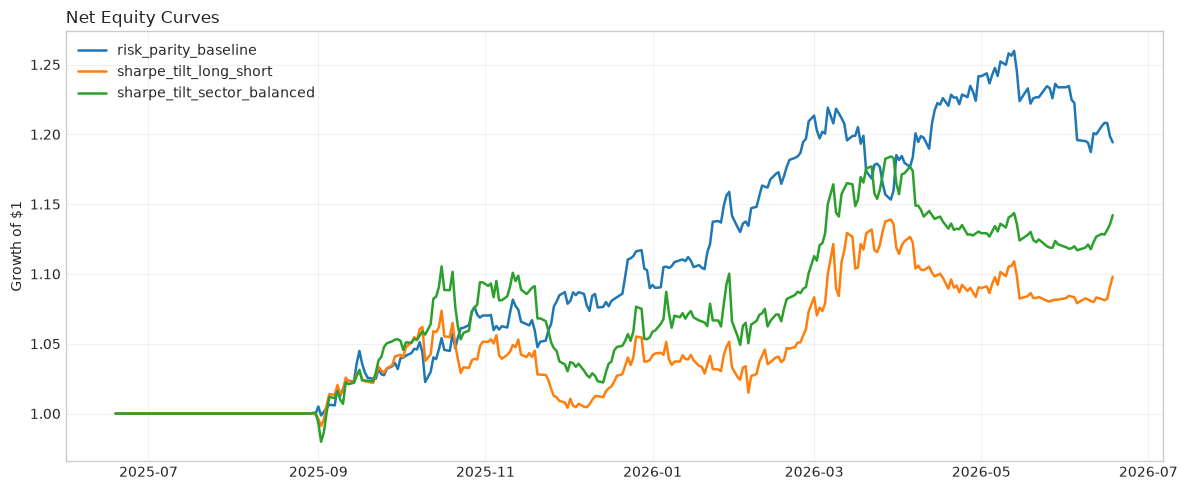

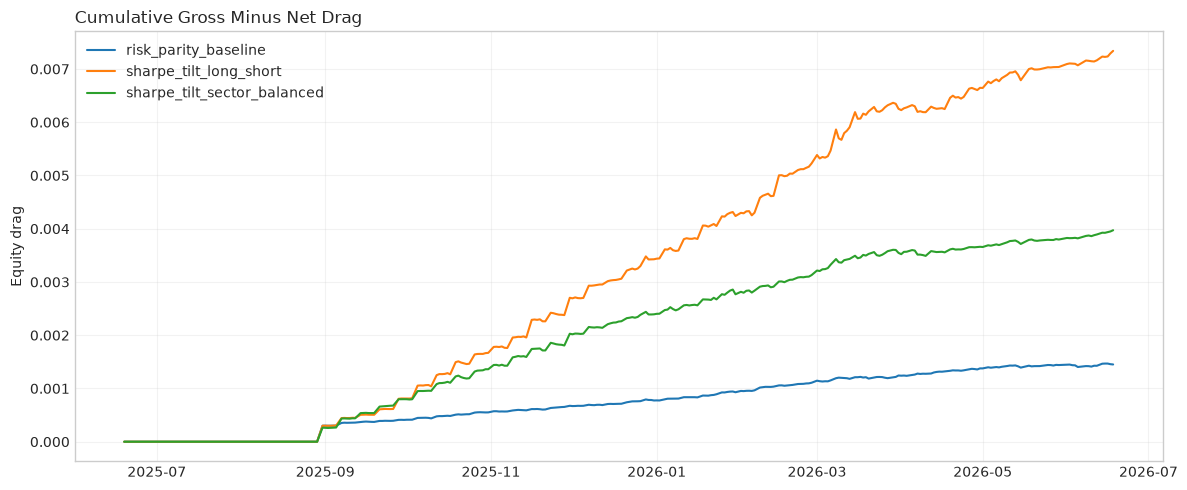

In [8]:
fig, ax = plt.subplots(figsize=(12, 5))
for name, result in results_by_strategy.items():
    ax.plot(result.index, result["equity_net"], label=name, linewidth=1.8)
ax.set_title("Net Equity Curves", loc="left")
ax.set_ylabel("Growth of $1")
ax.legend(loc="upper left")
ax.grid(True, alpha=0.25)
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(12, 5))
for name, result in results_by_strategy.items():
    drag = result["equity_gross"] - result["equity_net"]
    ax.plot(result.index, drag, label=name, linewidth=1.5)
ax.set_title("Cumulative Gross Minus Net Drag", loc="left")
ax.set_ylabel("Equity drag")
ax.legend(loc="upper left")
ax.grid(True, alpha=0.25)
plt.tight_layout()
plt.show()

## Drawdowns And Rolling Strategy Sharpe

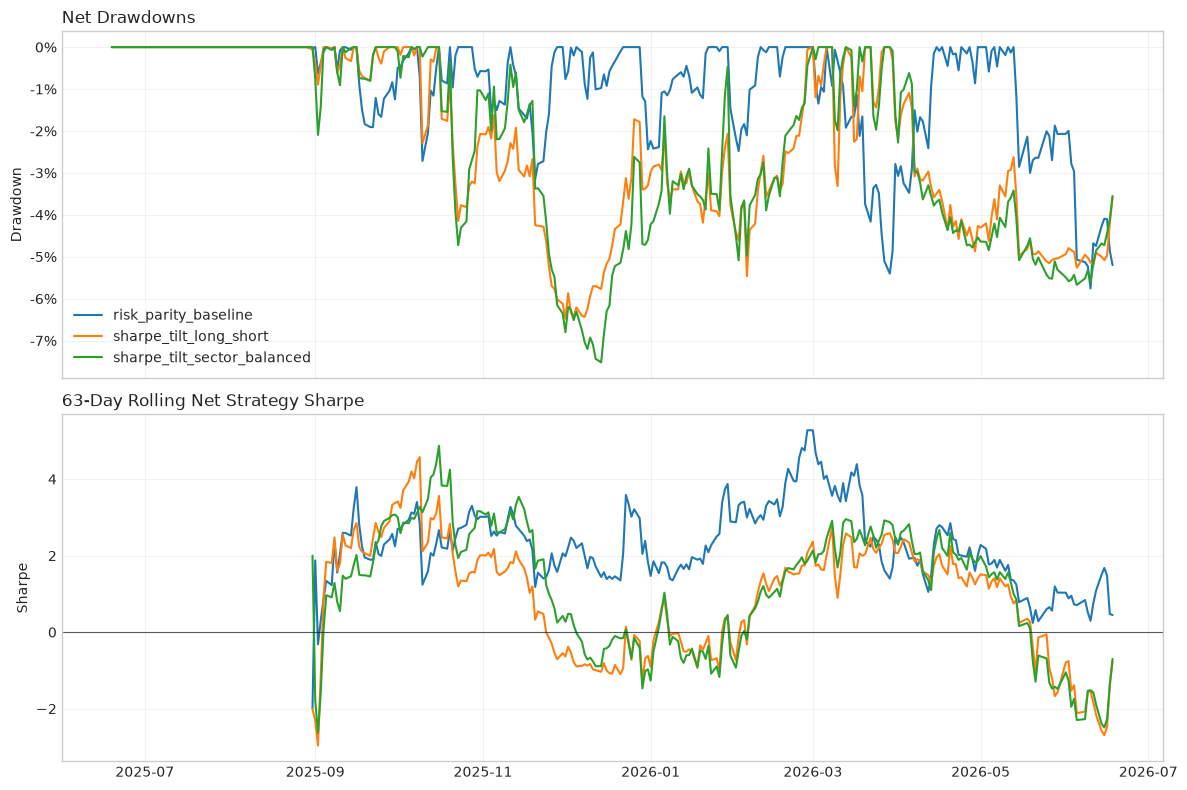

In [9]:
fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

for name, result in results_by_strategy.items():
    axes[0].plot(result.index, result["drawdown_net"], label=name, linewidth=1.5)
axes[0].set_title("Net Drawdowns", loc="left")
axes[0].set_ylabel("Drawdown")
axes[0].yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f"{y:.0%}"))
axes[0].legend(loc="lower left")
axes[0].grid(True, alpha=0.25)

for name, result in results_by_strategy.items():
    axes[1].plot(result.index, result["rolling_sharpe_63d_net"], label=name, linewidth=1.5)
axes[1].axhline(0, color="#111827", linewidth=0.8, alpha=0.7)
axes[1].set_title("63-Day Rolling Net Strategy Sharpe", loc="left")
axes[1].set_ylabel("Sharpe")
axes[1].grid(True, alpha=0.25)

plt.tight_layout()
plt.show()

## Turnover, Cost, And Leverage

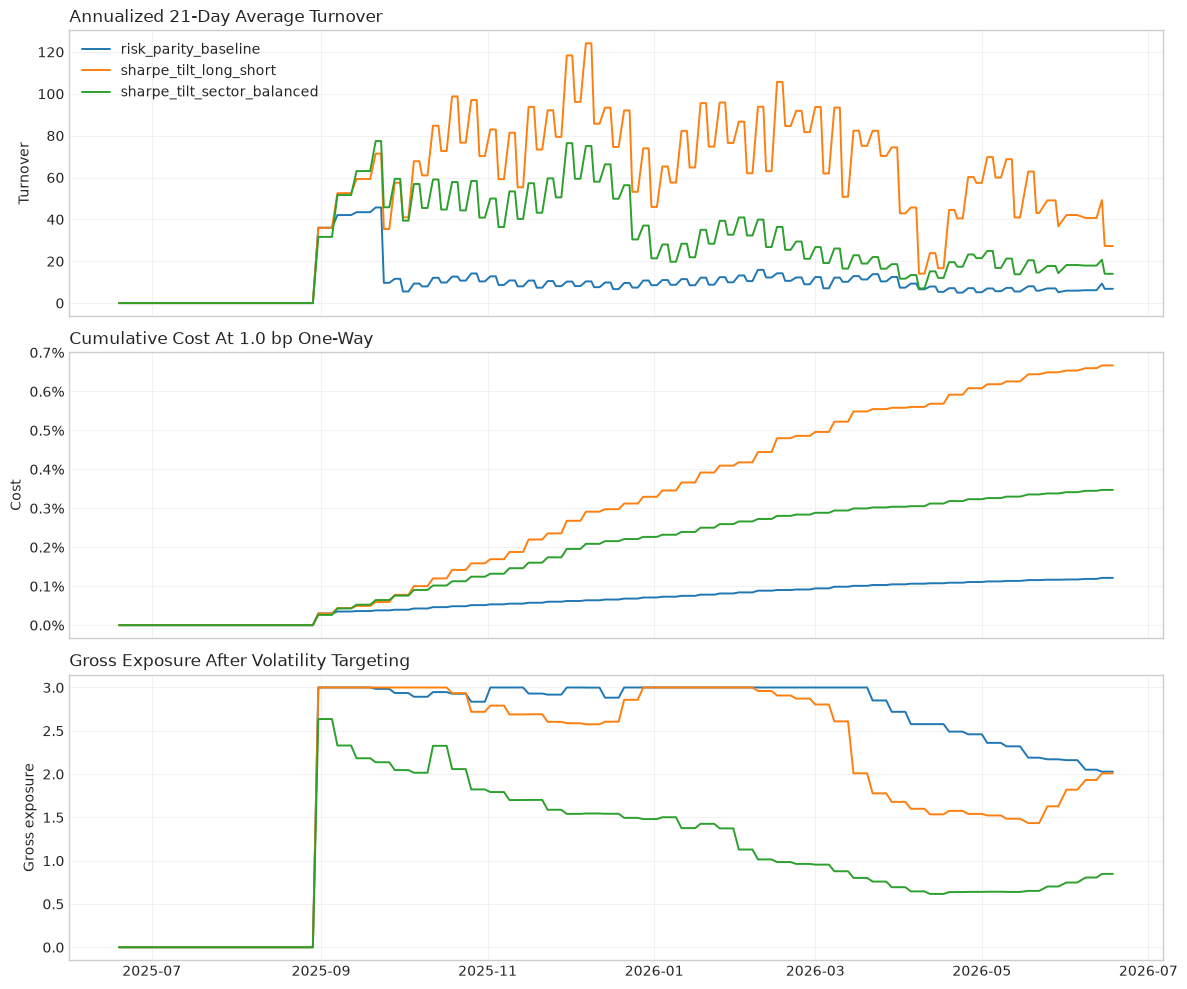

In [10]:
fig, axes = plt.subplots(3, 1, figsize=(12, 10), sharex=True)

for name, result in results_by_strategy.items():
    axes[0].plot(
        result.index,
        result["turnover"].rolling(21, min_periods=1).mean() * TRADING_DAYS_PER_YEAR,
        label=name,
        linewidth=1.4,
    )
axes[0].set_title("Annualized 21-Day Average Turnover", loc="left")
axes[0].set_ylabel("Turnover")
axes[0].legend(loc="upper left")
axes[0].grid(True, alpha=0.25)

for name, result in results_by_strategy.items():
    axes[1].plot(
        result.index,
        result["cost"].cumsum(),
        label=name,
        linewidth=1.4,
    )
axes[1].set_title(f"Cumulative Cost At {COST_BPS:.1f} bp One-Way", loc="left")
axes[1].set_ylabel("Cost")
axes[1].yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f"{y:.1%}"))
axes[1].grid(True, alpha=0.25)

for name, result in results_by_strategy.items():
    axes[2].plot(result.index, result["gross_exposure"], label=name, linewidth=1.4)
axes[2].set_title("Gross Exposure After Volatility Targeting", loc="left")
axes[2].set_ylabel("Gross exposure")
axes[2].grid(True, alpha=0.25)

plt.tight_layout()
plt.show()

## Sector Gross Exposure

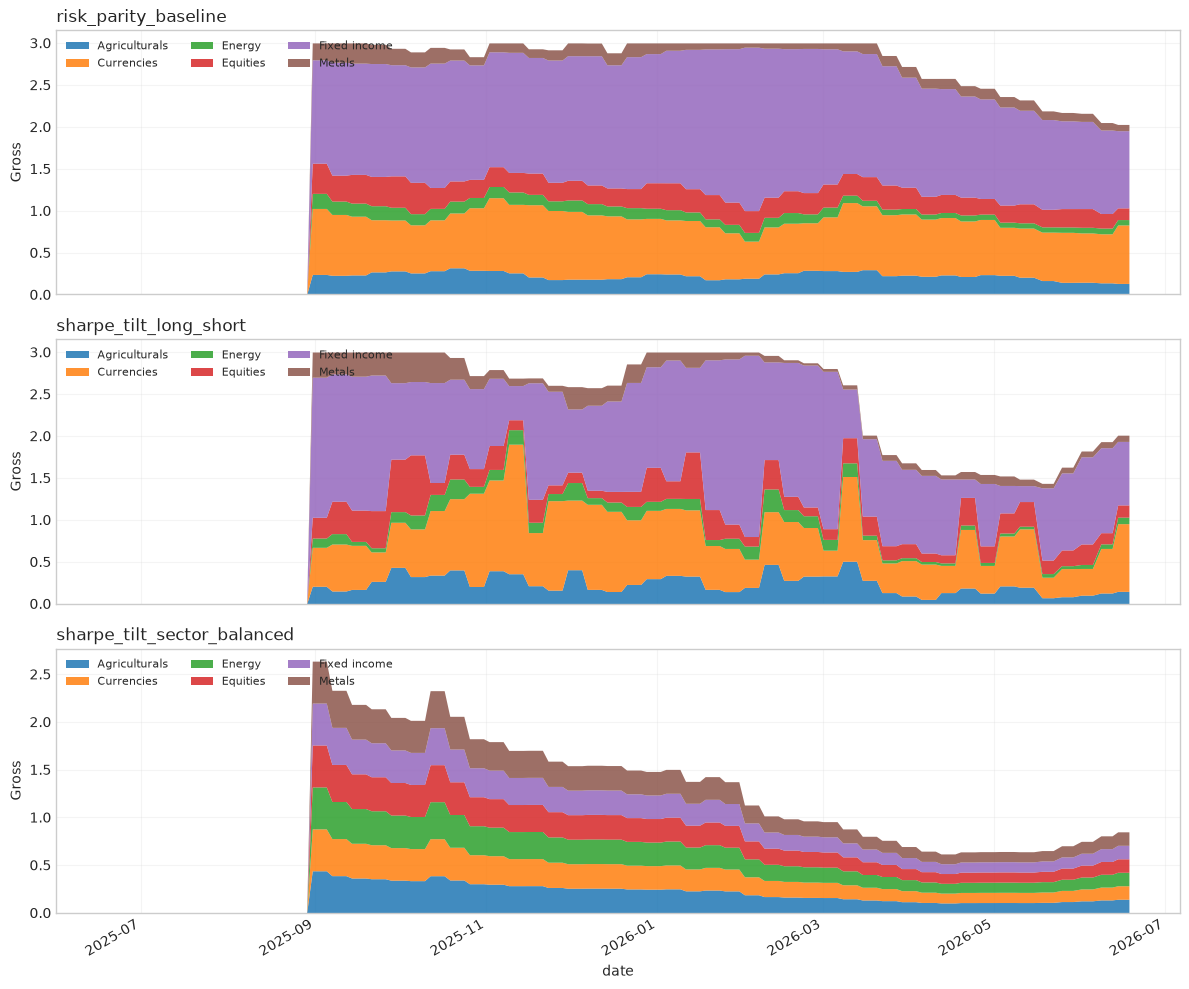

In [11]:
def sector_gross_exposure(weights: pd.DataFrame, metadata: pd.DataFrame) -> pd.DataFrame:
    exposures = {}
    for sector, group in metadata.groupby("category"):
        symbols = [symbol for symbol in group["symbol"] if symbol in weights.columns]
        exposures[sector] = weights[symbols].abs().sum(axis=1)
    return pd.DataFrame(exposures).fillna(0.0)


fig, axes = plt.subplots(len(weights_by_strategy), 1, figsize=(12, 10), sharex=True)
for ax, (name, weights) in zip(axes, weights_by_strategy.items(), strict=True):
    sector_exposure = sector_gross_exposure(weights, meta)
    sector_exposure.plot.area(ax=ax, linewidth=0, alpha=0.85)
    ax.set_title(name, loc="left")
    ax.set_ylabel("Gross")
    ax.legend(loc="upper left", ncols=3, fontsize=8)
    ax.grid(True, alpha=0.2)
plt.tight_layout()
plt.show()

## Latest Portfolio Weights

In [12]:
latest_weight_rows = []
for name, weights in weights_by_strategy.items():
    active_weights = weights.loc[weights.abs().sum(axis=1) > 0]
    latest_date = active_weights.index.max()
    latest = active_weights.loc[latest_date].rename("weight").reset_index()
    latest["strategy"] = name
    latest["date"] = latest_date
    latest_weight_rows.append(latest)

latest_weights = (
    pd.concat(latest_weight_rows, ignore_index=True)
    .merge(meta, on="symbol", how="left")
    .sort_values(["strategy", "category", "symbol"])[
        ["strategy", "date", "category", "symbol", "description", "weight"]
    ]
)

display(latest_weights.style.format({"weight": "{:.2%}"}))

,strategy,date,category,symbol,description,weight
22,risk_parity_baseline,2026-06-18 00:00:00,Agriculturals,ZC.v.0,Corn,2.38%
24,risk_parity_baseline,2026-06-18 00:00:00,Agriculturals,ZL.v.0,Soybean Oil,2.66%
25,risk_parity_baseline,2026-06-18 00:00:00,Agriculturals,ZM.v.0,Soybean Meal,3.14%
27,risk_parity_baseline,2026-06-18 00:00:00,Agriculturals,ZS.v.0,Soybeans,3.30%
29,risk_parity_baseline,2026-06-18 00:00:00,Agriculturals,ZW.v.0,CBOT Wheat,1.73%
0,risk_parity_baseline,2026-06-18 00:00:00,Currencies,6A.v.0,Australian Dollar,7.36%
1,risk_parity_baseline,2026-06-18 00:00:00,Currencies,6B.v.0,British Pound,9.73%
2,risk_parity_baseline,2026-06-18 00:00:00,Currencies,6C.v.0,Canadian Dollar,22.07%
3,risk_parity_baseline,2026-06-18 00:00:00,Currencies,6E.v.0,Euro FX,13.42%
4,risk_parity_baseline,2026-06-18 00:00:00,Currencies,6J.v.0,Japanese Yen,17.14%


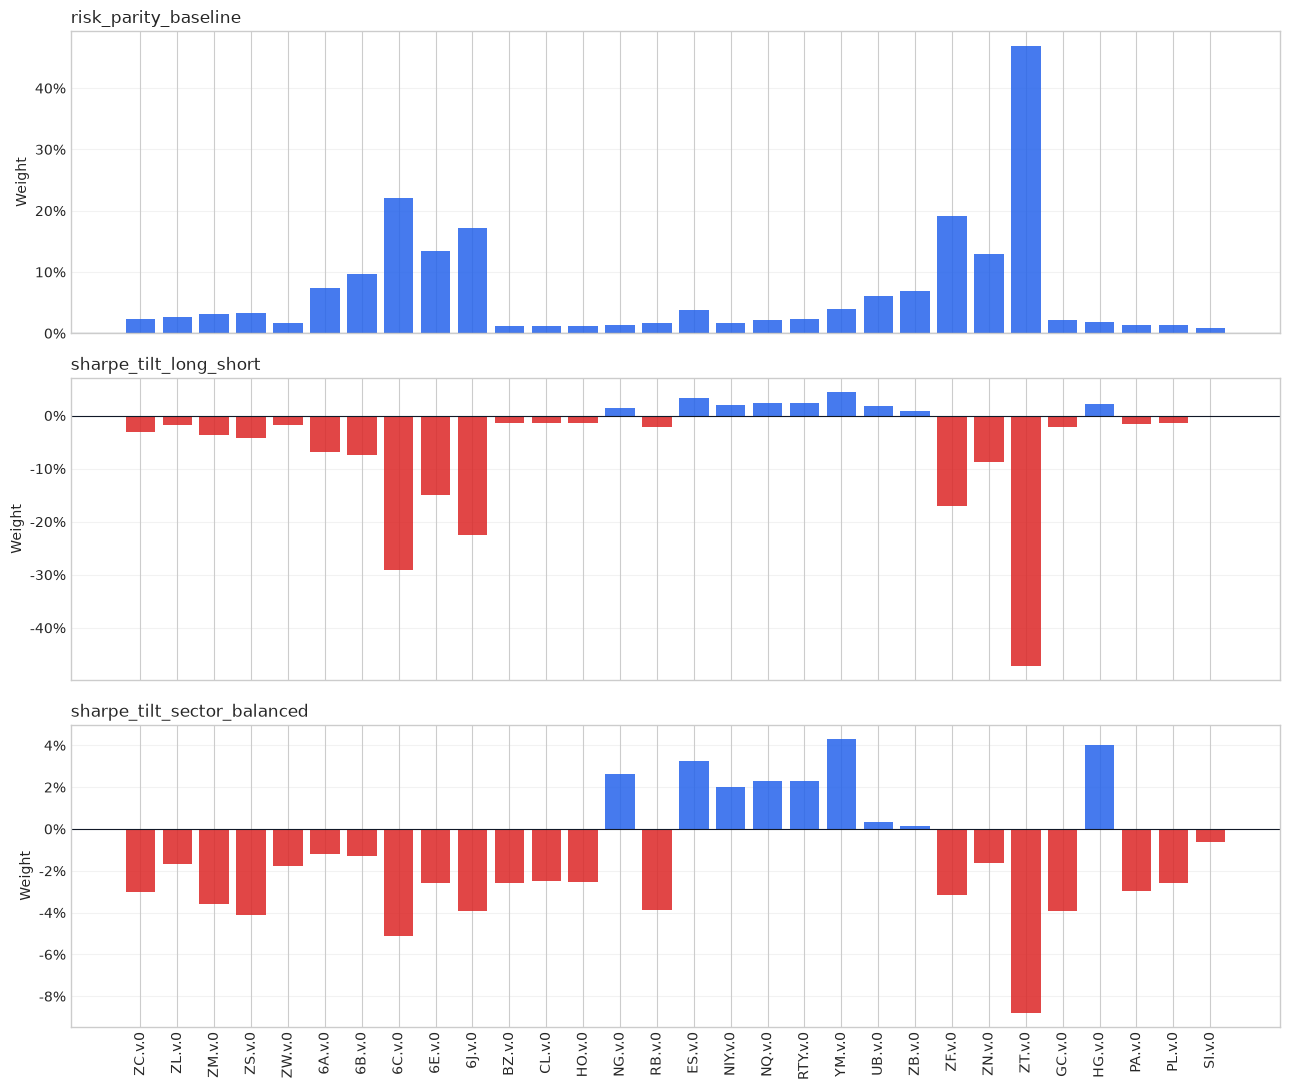

In [13]:
fig, axes = plt.subplots(len(weights_by_strategy), 1, figsize=(13, 11), sharex=True)
ordered_symbols = meta.sort_values(["category", "symbol"])["symbol"].tolist()

for ax, (name, weights) in zip(axes, weights_by_strategy.items(), strict=True):
    active_weights = weights.loc[weights.abs().sum(axis=1) > 0]
    latest = active_weights.iloc[-1].reindex(ordered_symbols)
    colors = np.where(latest >= 0, "#2563eb", "#dc2626")
    ax.bar(latest.index, latest.values, color=colors, alpha=0.85)
    ax.axhline(0, color="#111827", linewidth=0.8)
    ax.set_title(name, loc="left")
    ax.set_ylabel("Weight")
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f"{y:.0%}"))
    ax.grid(True, axis="y", alpha=0.25)

axes[-1].tick_params(axis="x", rotation=90)
plt.tight_layout()
plt.show()

## Interpretation Notes

- The backtest uses continuous futures close-to-close returns from the cached Databento-derived daily close series. It does not use official settlement prices.
- Signals are lagged by one observation after weekly rebalance scheduling to reduce lookahead risk.
- Costs are modeled as fixed basis points on notional turnover, not exchange fees, bid-ask spread, market impact, margin, or contract-specific tick economics.
- This is a one-year sample, so the results are a screening artifact, not evidence of a durable edge.
- The first active date starts after both asset-level signal warmup and portfolio-level volatility-target warmup.